# Gradient-Based Optimization (Twin Experiment)

Because SeapoPym is built entirely on JAX, the simulation is **end-to-end
differentiable**. This means we can compute exact gradients of a loss function
with respect to model parameters using `jax.value_and_grad`, and optimize
parameters via gradient descent.

**What you will learn:**

1. How to set up a **twin experiment** (generate observations from the model itself).
2. How to use `GradientOptimizer` with the Adam algorithm.
3. How parameter **scaling** (`"bounds"`) improves convergence.
4. How noise in observations affects parameter recovery.


In [1]:
import time

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr

import seapopym.functions.lmtl  # register LMTL physics functions
from seapopym.blueprint import Config
from seapopym.compiler import compile_model
from seapopym.engine import build_step_fn, run
from seapopym.models import LMTL_NO_TRANSPORT
from seapopym.optimization import GradientOptimizer, Objective
from seapopym.optimization.prior import PriorSet

print(f"JAX version: {jax.__version__}")
print(f"JAX devices: {jax.devices()}")

JAX version: 0.9.0.1
JAX devices: [CpuDevice(id=0)]


## 1. Twin Experiment Setup

A **twin experiment** validates an optimizer by:

1. Running the model with **known "true" parameters** to produce synthetic observations.
2. Starting from **different initial guesses** and optimizing to recover the true values.

If the optimizer works correctly, it should recover the true parameters (or get very
close) from the observations.

We optimize **3 parameters** while keeping the others fixed:

| Parameter      | Description                            | True Value |
| -------------- | -------------------------------------- | ---------- |
| `efficiency`   | NPP transfer efficiency                | 0.1668     |
| `gamma_lambda` | Thermal sensitivity of mortality       | 0.15 /°C   |
| `gamma_tau_r`  | Thermal sensitivity of recruitment age | 0.11 /°C   |

The optimizer starts from **perturbed initial guesses** (50% of the true values) —
not from the true values — to demonstrate genuine parameter recovery.


In [2]:
# --- True parameter values ---
TRUE_PARAMS = {
    "lambda_0": 1 / 150 / 86400,
    "gamma_lambda": 0.15,
    "tau_r_0": 10.38 * 86400,
    "gamma_tau_r": 0.11,
    "efficiency": 0.1668,
    "t_ref": 0.0,
}

# Parameters to optimize (3 out of 6)
OPT_PARAM_NAMES = ["efficiency", "gamma_lambda", "gamma_tau_r"]
BOUNDS = {
    "efficiency": (0.01, 5 * TRUE_PARAMS["efficiency"]),
    "gamma_lambda": (0.01, 5 * TRUE_PARAMS["gamma_lambda"]),
    "gamma_tau_r": (0.01, 5 * TRUE_PARAMS["gamma_tau_r"]),
}

# Initial guesses: 50% of true values (deliberately wrong)
INIT_PARAMS = {k: 0.5 * TRUE_PARAMS[k] for k in OPT_PARAM_NAMES}

# --- Time setup ---
SPINUP_YEARS = 1
OPT_YEARS = 2
DT = "1d"
OBS_FRACTION = 0.10  # 10% of timesteps used as observations
SEED = 42

# --- Optimizer settings ---
N_STEPS = 300
LEARNING_RATE = 0.01
TOLERANCE = 1e-8

# --- Noise levels ---
NOISE_LEVELS = [0.0, 0.15]

print("Twin experiment configuration:")
print(f"  Optimized parameters: {OPT_PARAM_NAMES}")
print(f"  Bounds: { {k: (f'{lo:.4g}', f'{hi:.4g}') for k, (lo, hi) in BOUNDS.items()} }")
print(f"  Optimizer: Adam (lr={LEARNING_RATE}, {N_STEPS} steps, scaling=bounds)")
print(f"  Noise levels: {NOISE_LEVELS}")
print(f"\nInitial guesses (50% of true):")
for p in OPT_PARAM_NAMES:
    print(f"  {p:<14} init={INIT_PARAMS[p]:.4g}  true={TRUE_PARAMS[p]:.4g}")

Twin experiment configuration:
  Optimized parameters: ['efficiency', 'gamma_lambda', 'gamma_tau_r']
  Bounds: {'efficiency': ('0.01', '0.834'), 'gamma_lambda': ('0.01', '0.75'), 'gamma_tau_r': ('0.01', '0.55')}
  Optimizer: Adam (lr=0.01, 300 steps, scaling=bounds)
  Noise levels: [0.0, 0.15]

Initial guesses (50% of true):
  efficiency     init=0.0834  true=0.1668
  gamma_lambda   init=0.075  true=0.15
  gamma_tau_r    init=0.055  true=0.11


## 2. Model & Forcings

We use the `LMTL_NO_TRANSPORT` blueprint on a **1×1 grid** (0D in space) with
synthetic seasonal forcings — identical to the
[first example](01_lmtl_no_transport.ipynb).

The model is compiled with **perturbed parameters** (50% of true values). The
optimizer will start from these wrong values and try to recover the truth.


In [3]:
blueprint = LMTL_NO_TRANSPORT

# --- Time ---
total_years = SPINUP_YEARS + OPT_YEARS
start_date = "2000-01-01"
end_date = str((pd.Timestamp(start_date) + pd.DateOffset(years=total_years)).date())

start_pd = pd.to_datetime(start_date)
end_pd = pd.to_datetime(end_date)
n_days = (end_pd - start_pd).days + 5
dates = pd.date_range(start=start_pd, periods=n_days, freq="D")
doy = dates.dayofyear.values.astype(float)

# --- Grid (1×1) ---
ny, nx = 1, 1
lat, lon = np.arange(ny), np.arange(nx)

# --- Cohort ages (use upper bound of tau_r_0 for safety) ---
max_age_days = int(np.ceil(BOUNDS.get("tau_r_0", (0, TRUE_PARAMS["tau_r_0"] * 5))[1] / 86400))
cohort_ages_sec = np.arange(0, max_age_days + 1) * 86400.0
n_cohorts = len(cohort_ages_sec)

# --- Forcings ---
temp_c = 15.0 + 5.0 * np.sin(2 * np.pi * doy / 365.0)
temp_4d = np.broadcast_to(temp_c[:, None, None, None], (len(dates), 1, ny, nx))

npp_day = 1.0 + 0.5 * np.sin(2 * np.pi * doy / 365.0)
npp_sec = npp_day / 86400.0
npp_3d = np.broadcast_to(npp_sec[:, None, None], (len(dates), ny, nx))

# --- Config (with PERTURBED initial guesses for optimized params) ---
config = Config(
    parameters={
        "lambda_0": xr.DataArray([TRUE_PARAMS["lambda_0"]], dims=["F"]),
        "gamma_lambda": xr.DataArray([INIT_PARAMS["gamma_lambda"]], dims=["F"]),
        "tau_r_0": xr.DataArray([TRUE_PARAMS["tau_r_0"]], dims=["F"]),
        "gamma_tau_r": xr.DataArray([INIT_PARAMS["gamma_tau_r"]], dims=["F"]),
        "t_ref": xr.DataArray(TRUE_PARAMS["t_ref"]),
        "efficiency": xr.DataArray([INIT_PARAMS["efficiency"]], dims=["F"]),
        "cohort_ages": xr.DataArray(cohort_ages_sec, dims=["C"]),
        "day_layer": xr.DataArray([0], dims=["F"]),
        "night_layer": xr.DataArray([0], dims=["F"]),
    },
    forcings={
        "latitude": xr.DataArray(np.full(ny, 30.0), dims=["Y"], coords={"Y": lat}),
        "temperature": xr.DataArray(
            temp_4d, dims=["T", "Z", "Y", "X"],
            coords={"T": dates, "Z": np.arange(1), "Y": lat, "X": lon},
        ),
        "primary_production": xr.DataArray(
            npp_3d, dims=["T", "Y", "X"],
            coords={"T": dates, "Y": lat, "X": lon},
        ),
        "day_of_year": xr.DataArray(doy, dims=["T"], coords={"T": dates}),
    },
    initial_state={
        "biomass": xr.DataArray(np.zeros((1, ny, nx)), dims=["F", "Y", "X"], coords={"Y": lat, "X": lon}),
        "production": xr.DataArray(
            np.zeros((1, n_cohorts, ny, nx)), dims=["F", "C", "Y", "X"], coords={"Y": lat, "X": lon},
        ),
    },
    execution={
        "time_start": start_date,
        "time_end": end_date,
        "dt": DT,
        "forcing_interpolation": "linear",
    },
)

# --- Compile ---
model = compile_model(blueprint, config)
step_fn = build_step_fn(model, export_variables=["biomass"])
n_timesteps = model.n_timesteps
spinup_steps = int(SPINUP_YEARS / total_years * n_timesteps)

print(f"Model compiled: {n_timesteps} timesteps ({spinup_steps} spin-up)")
print(f"  dt = {model.dt:.0f}s ({model.dt / 3600:.0f}h)")

Model compiled: 1096 timesteps (365 spin-up)
  dt = 86400s (24h)


## 3. Synthetic Observations

We run the model with the **true parameters** (overriding the perturbed initial
values), then sample a subset of timesteps as observations. For the noisy
experiment, we add 15% Gaussian noise.


In [4]:
# Run with true parameters
true_params_jax = {k: jnp.array([TRUE_PARAMS[k]]) for k in OPT_PARAM_NAMES}
_, outputs_true = run(step_fn, model, dict(model.state), {**model.parameters, **true_params_jax})

biomass_true = outputs_true["biomass"]
# Mean over spatial dims → scalar time series
true_ts_full = jnp.mean(biomass_true, axis=tuple(range(1, biomass_true.ndim)))
true_ts = true_ts_full[spinup_steps:]
n_opt_steps = len(true_ts)

# Sample observations
rng = np.random.default_rng(SEED)
n_obs = max(2, int(OBS_FRACTION * n_opt_steps))
obs_local_idx = np.sort(rng.choice(n_opt_steps, size=n_obs, replace=False))
obs_global_idx = obs_local_idx + spinup_steps
obs_clean = np.array(true_ts[obs_local_idx])

dt_sec = model.dt
time_days = np.arange(n_opt_steps) * dt_sec / 86400.0

print(f"True biomass range (year 2-3): [{float(true_ts.min()):.6f}, {float(true_ts.max()):.6f}] g/m²")
print(f"Observations: {n_obs} points ({100 * n_obs / n_opt_steps:.0f}% of timesteps)")

True biomass range (year 2-3): [2.300462, 3.131231] g/m²
Observations: 73 points (10% of timesteps)


## 4. Gradient Optimization

We use `GradientOptimizer` with **Adam** and `scaling="bounds"` (parameters
normalized to [0, 1] for better conditioning).

The optimizer differentiates through the entire simulation via `jax.value_and_grad`
and updates parameters at each step. We run two experiments:

1. **Clean** — exact observations
2. **Noisy** — 15% Gaussian noise added to observations


In [5]:
# Helper: extract predictions at observation timesteps
def extract_predictions(outputs):
    biomass = outputs["biomass"]
    ts = jnp.mean(biomass, axis=tuple(range(1, biomass.ndim)))
    return ts[obs_global_idx]

# Run both experiments
all_results = {}

for noise_level in NOISE_LEVELS:
    label = "clean" if noise_level == 0.0 else f"noise={noise_level:.0%}"
    print(f"\n{'=' * 50}")
    print(f"Experiment: {label}")
    print(f"{'=' * 50}")

    # Add noise
    if noise_level > 0:
        noise_rng = np.random.default_rng(SEED + 1)
        noise = noise_rng.normal(0, noise_level * np.abs(obs_clean))
        obs_values = jnp.array(obs_clean + noise)
    else:
        obs_values = jnp.array(obs_clean)

    # Build objective and optimizer
    objective = Objective(observations=obs_values, transform=extract_predictions)
    optimizer = GradientOptimizer(
        objectives=[(objective, "mse", 1.0)],
        bounds=BOUNDS,
        priors=PriorSet({}),  # no prior penalty — bounds used for scaling only
        algorithm="adam",
        learning_rate=LEARNING_RATE,
        scaling="bounds",
        export_variables=["biomass"],
    )

    # Run
    t0 = time.time()
    result = optimizer.run(model, n_steps=N_STEPS, tolerance=TOLERANCE, progress_bar=True)
    elapsed = time.time() - t0

    all_results[noise_level] = {
        "result": result,
        "obs_values": np.array(obs_values),
        "elapsed": elapsed,
    }

    print(f"  Time: {elapsed:.1f}s — {result.n_iterations} iterations")
    print(f"  Final loss: {result.loss:.6e}")
    print(f"  {'Converged' if result.converged else 'Did not converge'}")
    print(f"\n  Parameter recovery:")
    for p in OPT_PARAM_NAMES:
        val = float(jnp.squeeze(result.params[p]))
        true_val = TRUE_PARAMS[p]
        ratio = val / true_val
        print(f"    {p:<14} = {val:>12.4g}  (true={true_val:.4g}, ratio={ratio:.4f})")


Experiment: clean



  [1/300] loss=2.1223e+00


  [16/300] loss=3.5877e-01


  [31/300] loss=1.1788e-01


  [46/300] loss=9.9136e-02

...


  [256/300] loss=1.6194e-01


  [271/300] loss=1.6179e-01


  [286/300] loss=1.6170e-01


  [300/300] loss=1.6164e-01


  Time: 41.4s — 300 iterations
  Final loss: 1.616420e-01
  Did not converge

  Parameter recovery:
    efficiency     =       0.1616  (true=0.1668, ratio=0.9691)
    gamma_lambda   =       0.1488  (true=0.15, ratio=0.9923)
    gamma_tau_r    =      0.07674  (true=0.11, ratio=0.6977)


## 5. Results

For each experiment (clean / noisy), we show:

1. **Loss curve** — convergence of the loss function over gradient steps
2. **Parameter trajectories** — how each parameter evolves toward its true value
3. **Biomass fit** — true vs optimized model output
4. **Obs vs Pred scatter** — quality of the fit at observation points


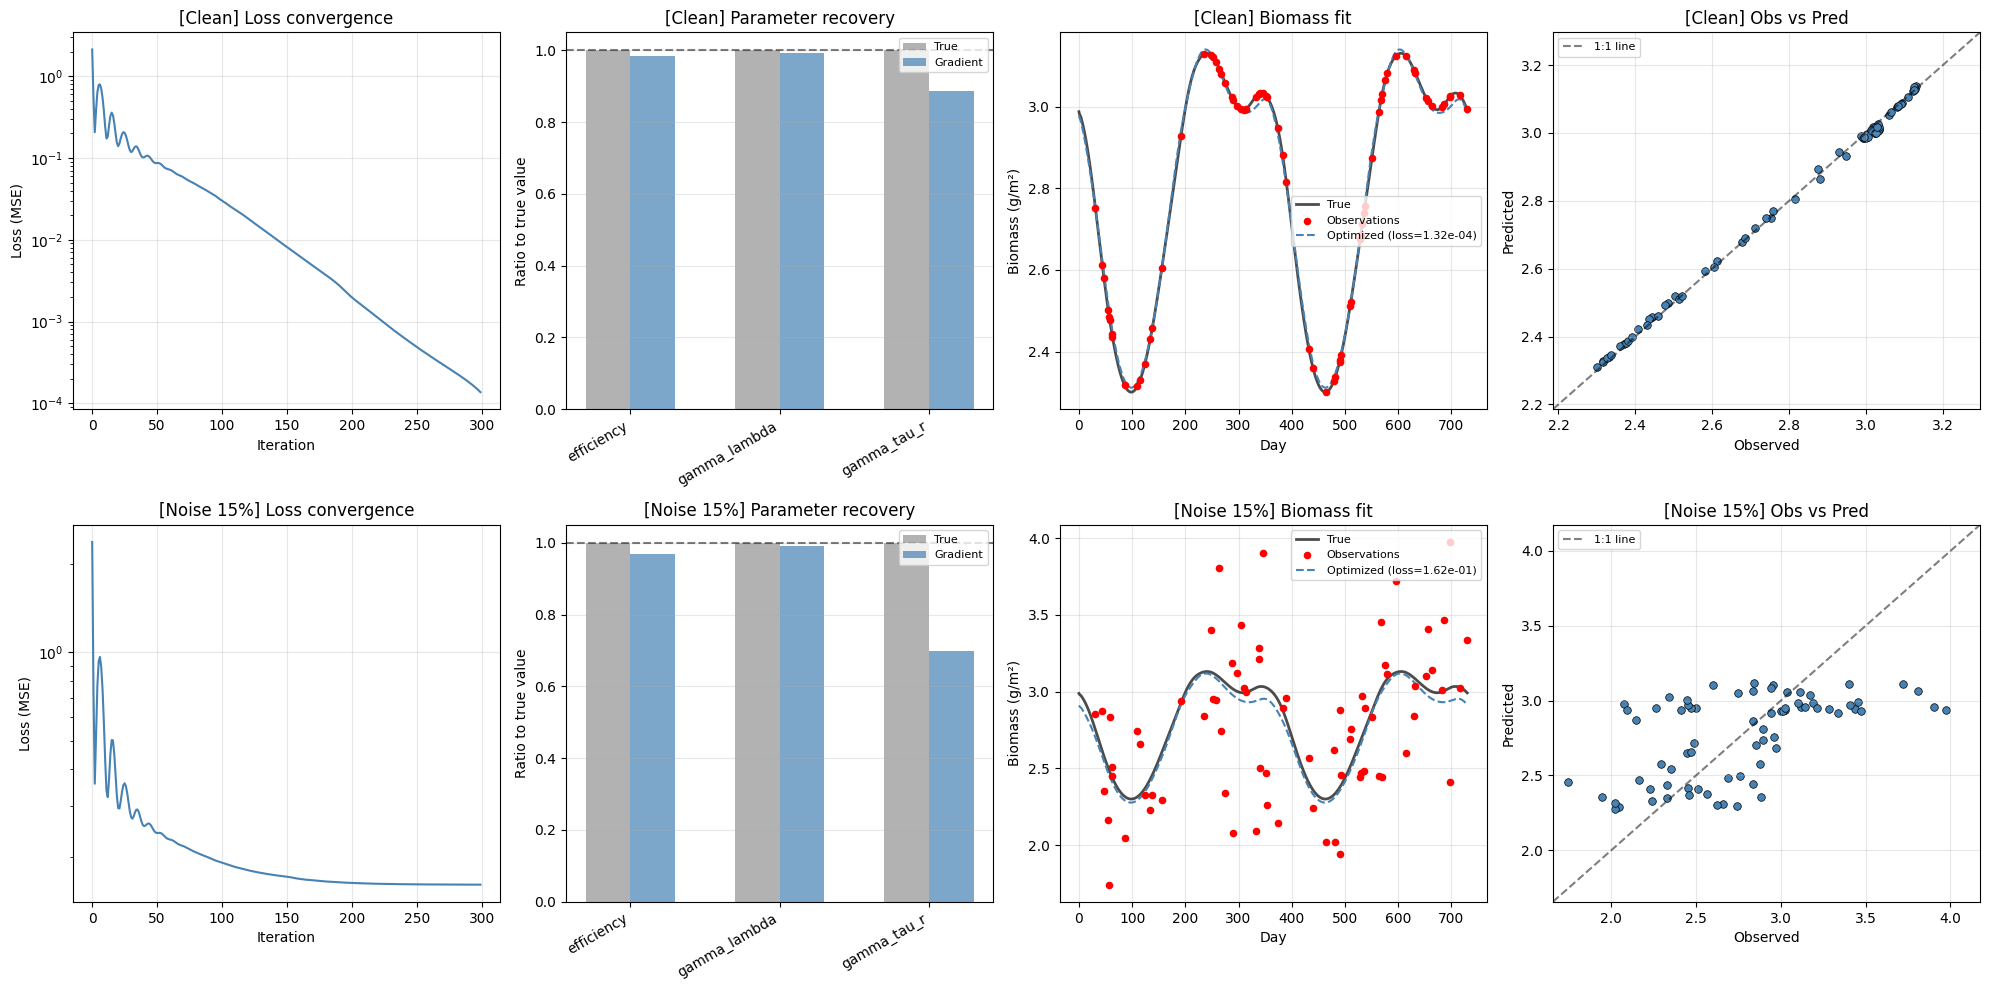

In [6]:
n_exp = len(NOISE_LEVELS)
fig, axes = plt.subplots(n_exp, 4, figsize=(20, 5 * n_exp))
if n_exp == 1:
    axes = axes[np.newaxis, :]

for row, noise_level in enumerate(NOISE_LEVELS):
    label = "Clean" if noise_level == 0.0 else f"Noise {noise_level:.0%}"
    exp = all_results[noise_level]
    result = exp["result"]
    obs_values = exp["obs_values"]

    # --- Col 0: Loss curve ---
    ax = axes[row, 0]
    ax.semilogy(result.loss_history, color="steelblue", linewidth=1.5)
    ax.set_xlabel("Iteration")
    ax.set_ylabel("Loss (MSE)")
    ax.set_title(f"[{label}] Loss convergence")
    ax.grid(True, alpha=0.3)

    # --- Col 1: Parameter recovery (bar chart) ---
    ax = axes[row, 1]
    x = np.arange(len(OPT_PARAM_NAMES))
    true_vals = np.array([TRUE_PARAMS[p] for p in OPT_PARAM_NAMES])
    opt_vals = np.array([float(jnp.squeeze(result.params[p])) for p in OPT_PARAM_NAMES])
    ratios = opt_vals / true_vals

    ax.bar(x - 0.15, np.ones(len(OPT_PARAM_NAMES)), 0.3, label="True", color="black", alpha=0.3)
    ax.bar(x + 0.15, ratios, 0.3, label="Gradient", color="steelblue", alpha=0.7)
    ax.axhline(y=1, color="k", linestyle="--", alpha=0.5)
    ax.set_xticks(x)
    ax.set_xticklabels(OPT_PARAM_NAMES, rotation=30, ha="right")
    ax.set_ylabel("Ratio to true value")
    ax.set_title(f"[{label}] Parameter recovery")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3, axis="y")

    # --- Col 2: Biomass time series ---
    ax = axes[row, 2]
    ax.plot(time_days, np.array(true_ts), "k-", linewidth=2, label="True", alpha=0.7)
    ax.scatter(
        obs_local_idx * dt_sec / 86400.0, obs_values,
        c="red", s=20, zorder=5, label="Observations",
    )
    # Run with optimized params
    _, outputs_opt = run(step_fn, model, dict(model.state), {**model.parameters, **result.params})
    bio_opt = outputs_opt["biomass"]
    opt_ts = jnp.mean(bio_opt, axis=tuple(range(1, bio_opt.ndim)))[spinup_steps:]
    ax.plot(time_days, np.array(opt_ts), "--", color="steelblue", linewidth=1.5,
            label=f"Optimized (loss={result.loss:.2e})")
    ax.set_xlabel("Day")
    ax.set_ylabel("Biomass (g/m²)")
    ax.set_title(f"[{label}] Biomass fit")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

    # --- Col 3: Obs vs Pred scatter ---
    ax = axes[row, 3]
    pred_at_obs = np.array(opt_ts[obs_local_idx])
    ax.scatter(obs_values, pred_at_obs, c="steelblue", edgecolors="k", linewidths=0.5, s=30)
    all_vals = np.concatenate([obs_values, pred_at_obs])
    lims = [all_vals.min() * 0.95, all_vals.max() * 1.05]
    ax.plot(lims, lims, "k--", alpha=0.5, label="1:1 line")
    ax.set_xlabel("Observed")
    ax.set_ylabel("Predicted")
    ax.set_title(f"[{label}] Obs vs Pred")
    ax.set_xlim(lims)
    ax.set_ylim(lims)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

fig.tight_layout()
plt.show()

## Summary

**Key takeaways:**

- Because the entire SeapoPym simulation is JAX-native, `jax.value_and_grad`
  computes **exact gradients** through the full model — no finite differences needed.
- `GradientOptimizer` with `scaling="bounds"` normalizes parameters to [0, 1],
  improving convergence when parameters have very different scales.
- On **clean observations**, gradient descent recovers the true parameters with
  high accuracy (ratio ≈ 1.0).
- With **noisy observations**, the optimizer still finds a good fit, but recovered
  parameters may deviate slightly from the true values — the optimizer fits the
  noise, not just the signal.

**When to use gradient optimization:**

| Scenario                | Gradient            | Evolutionary (GA, CMA-ES) |
| ----------------------- | ------------------- | ------------------------- |
| Smooth loss landscape   | Best choice         | Works but slower          |
| Non-smooth / noisy loss | May get stuck       | More robust               |
| Few parameters (< 10)   | Very fast           | Fine                      |
| Many parameters (> 50)  | Scales well         | Population size grows     |
| Need global search      | Finds local minimum | Better exploration        |

**Next steps:**

- [GA Optimization](05_optimization_ga.ipynb) — Evolutionary approach for the same problem.
- [CMA-ES](06_optimization_cmaes.ipynb) — Adaptive covariance strategies.
